# The Delta Method Explained

In A/B testing, we often analyze a ratio $R$ of two random variables, $X$ and $Y$ (aggregated at the user level):
$$\hat{r} = \frac{\bar{x}}{\bar{y}} = \frac{\sum X_i / n}{\sum Y_i / n}$$

The Delta Method provides a way to approximate the variance of this function using a  **Taylor expansion**.  

### Why is the Delta method so important? And why is it so complicated?
In A/B testing, $X$ (e.g., total clicks) and $Y$ (e.g., total sessions) are **highly correlated**. 
*   If a user has 100 sessions, they are much more likely to have more clicks than a user with 1 session.
*   The Delta Method accounts for this correlation. Using a standard t-test on $X_i/Y_i$ is inappropriate because it calculates the "Mean of Ratios" (which is susceptible to extreme outliers from users with low denominators), whereas the Delta Method correctly computes the variance for the "Ratio of Means."

### Requirements
* Normality: the ratio distribution must stabilizes into a normal curve.
* Large Sample Size ($n$):
	ratio metrics often require hundreds or thousands of users to ensure the ratio distribution stabilizes into a normal curve.
* Aggregated Unit-Level Data (Independence):
  The data must be aggregated to the **randomization unit** (usually the User). 
* A Non-Zero Denominator Mean:
  Because the formula involves dividing by the mean of the denominator ($\bar{Y}$), the average of your denominator must not be zero (and ideally, not extremely close to zero). 
* Absence of Extreme Outliers:
  Outlier removal or capping (winsorization) is often required before applying the Delta Method.

In [1]:
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt

control_num: np.ndarray  # X for control samples
control_den: np.ndarray  # Y for control samples

treatment_num: np.ndarray  # X for treatment samples
treatment_den: np.ndarray  # Y for treatment samples

### The Algorithm

1.  **Estimate Mean Ratio:** $\hat{r} = \frac{\bar{x}}{\bar{y}} = \frac{\sum X_i / n}{\sum Y_i / n}$

In [2]:
def get_mean_of_ratio(num, den):
    mu_x = np.mean(num)
    mu_y = np.mean(den)

    return mu_x / mu_y


2.  **Calculate Variance of Ratio for one user ($s^2_{ratio}$):**
    $$s^2_{ratio} = \frac{s^2_x}{\bar{y}^2} + \frac{\bar{x}^2 s^2_y}{\bar{y}^4} - \frac{2 \bar{x} s_{xy}}{\bar{y}^3}$$
    *(Where $s^2_x$ is sample variance of $X$, $s^2_y$ is sample variance of $Y$, and $s_{xy}$ is sample covariance).*

In [3]:
def get_var_of_ratio(num, den):
    mu_x = np.mean(num)
    mu_y = np.mean(den)

    var_x = np.var(num, ddof=1)
    var_y = np.var(den, ddof=1)
    cov_xy = np.cov(num, den)[0, 1]

    # Delta Method Formula for Variance of a Ratio (X/Y)
    var_ratio = (
        (var_x / (mu_y**2))
        + ((mu_x**2) * var_y / (mu_y**4))
        - (2 * mu_x * cov_xy / (mu_y**3))
    )

    return var_ratio

3.  **Average Treatment Effect (ATE)**, denoted as $\tau$:
    $$\tau = \hat{r_t} - \hat{r_c} $$

In [4]:
def get_average_treatment_effect(mean_treatment, mean_control):
    return mean_treatment - mean_control

4.  **Standard Error (SE):**
    $$SE = \sqrt{\frac{s^2_{ratio, \text{treatment}}}{n_t} + \frac{s^2_{ratio, \text{control}}}{n_c}}$$

In [5]:
def get_standard_error(var_treatment, n_treatment, var_control, n_control):
    return np.sqrt(var_treatment / n_treatment + var_control / n_control)

5.  **Z-score:**
    $$Z_{1-p/2} = \frac{\hat{r}_t - \hat{r}_c}{SE}$$

In [6]:
def get_z_score_and_p_value(mean_treatment, mean_control, se):
    z_score = (mean_treatment - mean_control) / se
    p_value = 2 * stats.norm.sf(np.abs(z_score))
    return z_score, p_value

6.  **Confidence interval:**
    $$CI = (\hat{r}_t - \hat{r}_c) \pm ME = \tau \pm Z_{1 - \alpha/2} \times SE$$

In [7]:
def get_confidence_interval(treatment_effect, alpha, se):

    z_crit = stats.norm.ppf(1 - alpha / 2)

    ci_lower = treatment_effect - z_crit * se
    ci_upper = treatment_effect + z_crit * se

    return ci_lower, ci_upper

In [8]:
def delta_method_ratio_test(
    control_num: np.ndarray,
    control_den: np.ndarray,
    treatment_num: np.ndarray,
    treatment_den: np.ndarray,
    alpha=0.05,
):
    """
    Calculates the Z-test for ratio metrics using the Delta Method.

    Parameters:
    - control_num/den: User-level numerator and denominator for control group (arrays).
    - treatment_num/den: User-level numerator and denominator for treatment group (arrays).
    """
    mean_control = get_mean_of_ratio(control_num, control_den)
    mean_treatment = get_mean_of_ratio(treatment_num, treatment_den)

    var_control = get_var_of_ratio(control_num, control_den)
    var_treatment = get_var_of_ratio(treatment_num, treatment_den)

    treatment_effect = get_average_treatment_effect(mean_treatment, mean_control)

    se = get_standard_error(
        var_treatment, len(treatment_num), var_control, len(control_num)
    )
    z_score, p_value = get_z_score_and_p_value(mean_treatment, mean_control, se)

    ci_lower, ci_upper = get_confidence_interval(treatment_effect, alpha, se)

    return {
        "control_mean": mean_control,
        "treatment_mean": mean_treatment,
        "treatment_effect": treatment_effect,
        "p_value": p_value,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
    }


#### Example Usage
Generate dummy user-level data
Each entry represents a user's total revenue (num) and total sessions (den).

*If you decrease the number of users, the test will lose statistical power, meaning it may fail to detect a significant difference even if one exists.*

In [9]:
n_users = 1000

Control: Average 1.0 revenue per 2 sessions

In [10]:
control_sess = np.random.poisson(2, n_users) + 1
control_rev = np.random.poisson(0.5 * control_sess)

In [11]:
def calc_bins(arr: np.ndarray):
    return np.arange(arr.min() - 0.5, arr.max() + 1.5)

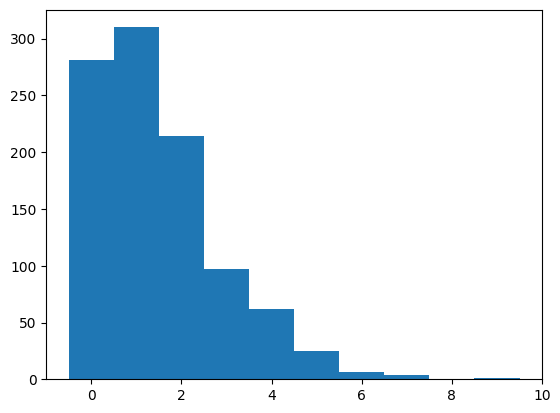

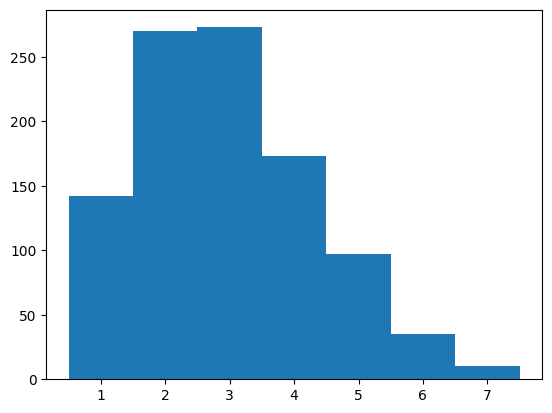

In [12]:
plt.hist(control_rev, bins=calc_bins(control_rev))
plt.show()

plt.hist(control_sess, bins=calc_bins(control_sess))
plt.show()

Treatment: Slight increase in revenue

In [13]:
treat_sess = np.random.poisson(2.1, n_users) + 1
treat_rev = np.random.poisson(0.57 * treat_sess)

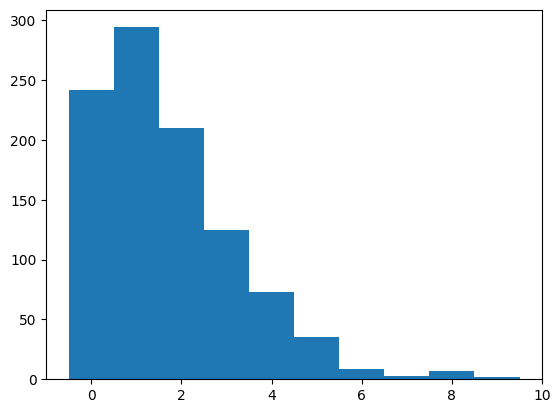

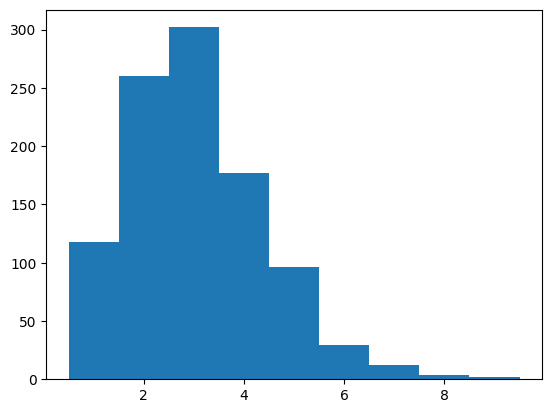

In [14]:
plt.hist(treat_rev, bins=calc_bins(treat_rev))
plt.show()

plt.hist(treat_sess, bins=calc_bins(treat_sess))
plt.show()

In [15]:
results = delta_method_ratio_test(control_rev, control_sess, treat_rev, treat_sess)

print(f"Control Ratio: {results['control_mean']:.4f}")
print(f"Treatment Ratio: {results['treatment_mean']:.4f}")
print(f"ATE: {results['treatment_effect']:.4f}")
print(f"P-value: {results['p_value']}")
print(f"95% CI: [{results['ci_lower']:.4f}, {results['ci_upper']:.4f}]")

print(
    "No difference in revenue per session between control and treatment groups."
    if results["p_value"] > 0.05
    else "There is a significant difference in revenue per session between control and treatment groups."
)

Control Ratio: 0.4986
Treatment Ratio: 0.5609
ATE: 0.0622
P-value: 0.0012006221290006538
95% CI: [0.0246, 0.0999]
There is a significant difference in revenue per session between control and treatment groups.


- [The Delta Method](https://en.wikipedia.org/wiki/Delta_method)
- [Average Treatment Effect](https://en.wikipedia.org/wiki/Average_treatment_effect)
- [P-value](https://wmed.edu/sites/default/files/P-VALUES%20SIMPLIFIED.pdf)
- [Confidence Interval from The Standard Error of the difference](https://stattrek.com/estimation/difference-in-means)